# Machine Learning for Predictive Maintenance

## Failure Prediction with Process, Engineered, and SPC Features

The objective of this section is to predict machine failures by combining:

1. Original process variables
2. Physically engineered features
3. Interpretable SPC-based abnormal-process signals

Model performance will be evaluated under severe class imbalance using metrics such as Precision, Recall, F1-score, ROC-AUC, and PR-AUC.

The test set will remain untouched until model selection and validation are completed.

# Machine Learning for Predictive Maintenance

## Failure Prediction Using Process, Engineered, and SPC Features

This section evaluates whether machine failures can be predicted using three progressively richer feature sets:

1. **Base Process Features**  
   Original operating variables only.

2. **Engineered Features**  
   Base variables plus physically derived temperature difference and mechanical power.

3. **SPC-Enhanced Features**  
   Engineered variables plus interpretable SPC alarm signals derived from torque, mechanical power, and rotational speed.

Because machine failures represent only a small proportion of the observations, model evaluation will emphasize Precision, Recall, F1-score, ROC-AUC, and PR-AUC rather than accuracy alone.

The test set remains untouched during model development and will be used only after model selection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [2]:
train_df = pd.read_csv("../data/processed/train_features.csv")
validation_df = pd.read_csv("../data/processed/validation_features.csv")
test_df = pd.read_csv("../data/processed/test_features.csv")

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

Train: (7000, 36)
Validation: (1500, 36)
Test: (1500, 30)


In [3]:
target = "Machine failure"

y_train = train_df[target]
y_val = validation_df[target]
y_test = test_df[target]

In [4]:
base_features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

In [5]:
engineered_feature_set = base_features + [
    "Temperature difference [K]",
    "Mechanical power [kW]"
]

In [6]:
spc_feature_set = engineered_feature_set + [
    "Torque_SPC_Alarm",
    "Power_SPC_Alarm",
    "RPM_SPC_Alarm"
]

In [7]:
X_train_A = train_df[base_features]
X_val_A = validation_df[base_features]

X_train_B = train_df[engineered_feature_set]
X_val_B = validation_df[engineered_feature_set]

X_train_C = train_df[spc_feature_set]
X_val_C = validation_df[spc_feature_set]

In [8]:
def build_logistic_pipeline(feature_list):

    categorical_features = [
        feature for feature in feature_list
        if feature == "Type"
    ]

    numeric_features = [
        feature for feature in feature_list
        if feature != "Type"
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                numeric_features
            ),
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore"),
                categorical_features
            )
        ]
    )

    model = LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    return pipeline

In [10]:
_ = model_A.fit(
    X_train_A,
    y_train
)

print("Model A training completed.")

Model A training completed.


In [11]:
# Validation prediction

val_pred_A = model_A.predict(X_val_A)

val_prob_A = model_A.predict_proba(X_val_A)[:, 1]

print("Prediction completed.")

Prediction completed.


In [12]:
# Model A validation performance

accuracy_A = accuracy_score(y_val, val_pred_A)
precision_A = precision_score(y_val, val_pred_A)
recall_A = recall_score(y_val, val_pred_A)
f1_A = f1_score(y_val, val_pred_A)
roc_auc_A = roc_auc_score(y_val, val_prob_A)
pr_auc_A = average_precision_score(y_val, val_prob_A)

print(f"Accuracy  : {accuracy_A:.4f}")
print(f"Precision : {precision_A:.4f}")
print(f"Recall    : {recall_A:.4f}")
print(f"F1-score  : {f1_A:.4f}")
print(f"ROC-AUC   : {roc_auc_A:.4f}")
print(f"PR-AUC    : {pr_auc_A:.4f}")

Accuracy  : 0.9593
Precision : 0.2769
Recall    : 0.5625
F1-score  : 0.3711
ROC-AUC   : 0.8855
PR-AUC    : 0.3595


In [13]:
cm_A = confusion_matrix(y_val, val_pred_A)

cm_A

array([[1421,   47],
       [  14,   18]])

In [14]:
tn, fp, fn, tp = cm_A.ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 1421
False Positive: 47
False Negative: 14
True Positive : 18


In [15]:
print(classification_report(
    y_val,
    val_pred_A,
    target_names=["Normal", "Failure"]
))

              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98      1468
     Failure       0.28      0.56      0.37        32

    accuracy                           0.96      1500
   macro avg       0.63      0.77      0.68      1500
weighted avg       0.98      0.96      0.97      1500



In [16]:
model_B = build_logistic_pipeline(engineered_feature_set)

_ = model_B.fit(
    X_train_B,
    y_train
)

print("Model B training completed.")

Model B training completed.


In [17]:
val_pred_B = model_B.predict(X_val_B)
val_prob_B = model_B.predict_proba(X_val_B)[:, 1]

In [18]:
model_C = build_logistic_pipeline(spc_feature_set)

_ = model_C.fit(
    X_train_C,
    y_train
)

print("Model C training completed.")

Model C training completed.


In [19]:
val_pred_C = model_C.predict(X_val_C)
val_prob_C = model_C.predict_proba(X_val_C)[:, 1]

In [20]:
def evaluate_model(y_true, y_pred, y_prob, model_name):

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    return results

In [21]:
results_A = evaluate_model(
    y_val,
    val_pred_A,
    val_prob_A,
    "Model A - Base"
)

results_B = evaluate_model(
    y_val,
    val_pred_B,
    val_prob_B,
    "Model B - Engineered"
)

results_C = evaluate_model(
    y_val,
    val_pred_C,
    val_prob_C,
    "Model C - SPC Enhanced"
)

comparison_df = pd.DataFrame([
    results_A,
    results_B,
    results_C
])

comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Model A - Base,0.9593,0.2769,0.5625,0.3711,0.8855,0.3595,1421,47,14,18
1,Model B - Engineered,0.9480,0.2386,0.6562,0.3500,0.9007,0.4480,1401,67,11,21
2,Model C - SPC Enhanced,0.9493,0.2500,0.6875,0.3667,0.9023,0.4458,1402,66,10,22


## Logistic Regression Feature-Set Comparison

Three logistic-regression models were evaluated using progressively richer feature sets.

### Model A — Base Process Features

The baseline model used only the original operating variables.

It identified 18 of the 32 machine failures in the validation set, corresponding to a failure recall of approximately 56.3%.

### Model B — Engineered Features

Model B additionally included temperature difference and mechanical power.

Failure recall increased from approximately 56.3% to 65.6%, while PR-AUC improved from approximately 0.360 to 0.448.

This result suggests that physically motivated feature engineering provided useful additional representations of the operating conditions.

Mechanical power combines torque and rotational speed, while temperature difference represents the thermal relationship between process and ambient conditions. These engineered variables can therefore encode interactions that are not represented as directly by the original variables alone.

However, the improved failure detection was accompanied by an increase in false-positive predictions, illustrating the trade-off between failure recall and false alarms.

### Model C — SPC-Enhanced Features

Model C additionally incorporated SPC alarm signals derived from torque, mechanical power, and rotational speed.

Failure recall increased slightly further to approximately 68.8%, with one additional failure detected relative to Model B.

However, the improvement was modest, and PR-AUC remained nearly unchanged. This suggests that SPC signals provide some complementary information but largely overlap with information already contained in the underlying process variables.

### Interpretation

The results indicate that feature engineering provides a clearer improvement than SPC feature augmentation for the current logistic-regression model.

The observed relationships should be interpreted as predictive associations rather than causal mechanisms. Improved prediction does not establish that torque, mechanical power, or other variables directly cause machine failures.

At this stage, the analysis identifies operating conditions associated with elevated failure risk rather than specific corrective actions.

Subsequent analysis will examine model coefficients, non-linear machine-learning models, and failure-mode relationships to better understand which process conditions contribute most strongly to failure prediction.

In [22]:
# Get fitted preprocessor and logistic regression model

preprocessor_C = model_C.named_steps["preprocessor"]
logistic_C = model_C.named_steps["model"]

feature_names_C = preprocessor_C.get_feature_names_out()

coefficients_C = logistic_C.coef_[0]

coef_df_C = pd.DataFrame({
    "Feature": feature_names_C,
    "Coefficient": coefficients_C
})

coef_df_C["Abs_Coefficient"] = coef_df_C["Coefficient"].abs()

coef_df_C = coef_df_C.sort_values(
    "Abs_Coefficient",
    ascending=False
)

coef_df_C

,Feature,Coefficient,Abs_Coefficient
3,num__Torque [Nm],7.453696,7.453696
6,num__Mechanical power [kW],-4.420485,4.420485
2,num__Rotational speed [rpm],2.301072,2.301072
4,num__Tool wear [min],0.893687,0.893687
5,num__Temperature difference [K],-0.832460,0.832460
12,cat__Type_M,-0.521029,0.521029
10,cat__Type_H,-0.369734,0.369734
11,cat__Type_L,-0.334388,0.334388
1,num__Process temperature [K],-0.228688,0.228688
0,num__Air temperature [K],0.184257,0.184257


In [23]:
coef_df_C["Feature"] = (
    coef_df_C["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

coef_df_C

,Feature,Coefficient,Abs_Coefficient
3,Torque [Nm],7.453696,7.453696
6,Mechanical power [kW],-4.420485,4.420485
2,Rotational speed [rpm],2.301072,2.301072
4,Tool wear [min],0.893687,0.893687
5,Temperature difference [K],-0.832460,0.832460
12,Type_M,-0.521029,0.521029
10,Type_H,-0.369734,0.369734
11,Type_L,-0.334388,0.334388
1,Process temperature [K],-0.228688,0.228688
0,Air temperature [K],0.184257,0.184257


In [24]:
coef_df_C["Odds_Ratio"] = np.exp(
    coef_df_C["Coefficient"]
)

coef_df_C[
    ["Feature", "Coefficient", "Odds_Ratio"]
].round(3)

,Feature,Coefficient,Odds_Ratio
3,Torque [Nm],7.454,1726.232
6,Mechanical power [kW],-4.420,0.012
2,Rotational speed [rpm],2.301,9.985
4,Tool wear [min],0.894,2.444
5,Temperature difference [K],-0.832,0.435
12,Type_M,-0.521,0.594
10,Type_H,-0.370,0.691
11,Type_L,-0.334,0.716
1,Process temperature [K],-0.229,0.796
0,Air temperature [K],0.184,1.202


In [25]:
top_coef_C = coef_df_C.head(12)

top_coef_C[
    ["Feature", "Coefficient", "Odds_Ratio"]
].round(3)

,Feature,Coefficient,Odds_Ratio
3,Torque [Nm],7.454,1726.232
6,Mechanical power [kW],-4.420,0.012
2,Rotational speed [rpm],2.301,9.985
4,Tool wear [min],0.894,2.444
5,Temperature difference [K],-0.832,0.435
12,Type_M,-0.521,0.594
10,Type_H,-0.370,0.691
11,Type_L,-0.334,0.716
1,Process temperature [K],-0.229,0.796
0,Air temperature [K],0.184,1.202


In [27]:
import os

os.makedirs("../figures/ml", exist_ok=True)

def save_ml_fig(filename):
    plt.savefig(
        f"../figures/ml/{filename}",
        dpi=300,
        bbox_inches="tight"
    )

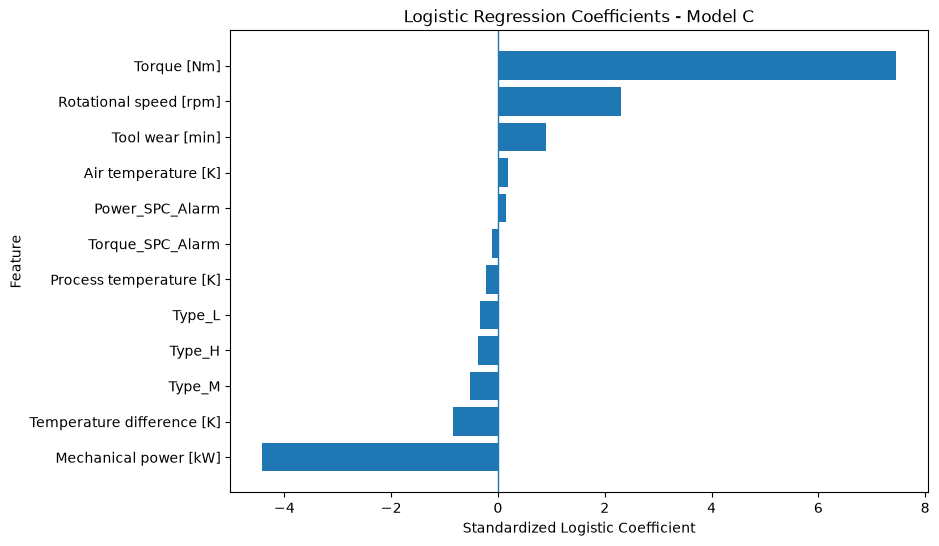

In [28]:
plot_coef = (
    coef_df_C
    .head(12)
    .sort_values("Coefficient")
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_coef["Feature"],
    plot_coef["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.title("Logistic Regression Coefficients - Model C")
plt.xlabel("Standardized Logistic Coefficient")
plt.ylabel("Feature")

save_ml_fig("model_c_logistic_coefficients.png")
plt.show()

### Interpretation of Logistic Regression Coefficients

The coefficient analysis revealed that torque received a large positive coefficient, whereas mechanical power received a large negative coefficient.

These coefficients should not be interpreted as independent causal effects.

Mechanical power was engineered directly from torque and rotational speed, and previous exploratory analysis showed that mechanical power and torque are highly correlated. Therefore, including torque, rotational speed, and mechanical power simultaneously introduces substantial multicollinearity.

Under multicollinearity, logistic-regression coefficients may become unstable in magnitude and sign because the model attempts to distribute overlapping predictive information across correlated variables.

Consequently, the large positive torque coefficient and negative mechanical-power coefficient do not imply that torque causes failure while mechanical power prevents failure. Rather, they indicate that the combined mechanical operating state contains substantial predictive information, while the independent contribution of each strongly correlated feature cannot be reliably inferred from these coefficients alone.

SPC alarm coefficients were comparatively small. This is reasonable because the SPC indicators are derived from the same continuous variables already provided to the model. They therefore contribute primarily threshold-based information about extreme process states rather than entirely new process information.

The SPC-enhanced model produced a modest improvement in failure recall, but the coefficient analysis suggests that most predictive information remains contained in the underlying continuous process variables.

A subsequent ablation analysis will evaluate whether mechanical power contributes predictive information beyond its constituent torque and rotational-speed variables.

In [29]:
# Ablation feature sets

ablation_full_features = spc_feature_set.copy()

ablation_no_power_features = [
    feature for feature in spc_feature_set
    if feature not in [
        "Mechanical power [kW]",
        "Power_SPC_Alarm"
    ]
]

ablation_power_substitute_features = [
    feature for feature in spc_feature_set
    if feature not in [
        "Torque [Nm]",
        "Rotational speed [rpm]",
        "Torque_SPC_Alarm",
        "RPM_SPC_Alarm"
    ]
]

print("Full:", ablation_full_features)
print("\nNo Power:", ablation_no_power_features)
print("\nPower Substitute:", ablation_power_substitute_features)

Full: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature difference [K]', 'Mechanical power [kW]', 'Torque_SPC_Alarm', 'Power_SPC_Alarm', 'RPM_SPC_Alarm']

No Power: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature difference [K]', 'Torque_SPC_Alarm', 'RPM_SPC_Alarm']

Power Substitute: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Tool wear [min]', 'Temperature difference [K]', 'Mechanical power [kW]', 'Power_SPC_Alarm']


In [30]:
X_train_full = train_df[ablation_full_features]
X_val_full = validation_df[ablation_full_features]

X_train_no_power = train_df[ablation_no_power_features]
X_val_no_power = validation_df[ablation_no_power_features]

X_train_power_sub = train_df[ablation_power_substitute_features]
X_val_power_sub = validation_df[ablation_power_substitute_features]

In [31]:
ablation_full_model = build_logistic_pipeline(
    ablation_full_features
)

_ = ablation_full_model.fit(
    X_train_full,
    y_train
)

ablation_no_power_model = build_logistic_pipeline(
    ablation_no_power_features
)

_ = ablation_no_power_model.fit(
    X_train_no_power,
    y_train
)

ablation_power_sub_model = build_logistic_pipeline(
    ablation_power_substitute_features
)

_ = ablation_power_sub_model.fit(
    X_train_power_sub,
    y_train
)

print("Ablation models trained.")

Ablation models trained.


In [32]:
pred_full = ablation_full_model.predict(X_val_full)
prob_full = ablation_full_model.predict_proba(X_val_full)[:, 1]

pred_no_power = ablation_no_power_model.predict(X_val_no_power)
prob_no_power = ablation_no_power_model.predict_proba(X_val_no_power)[:, 1]

pred_power_sub = ablation_power_sub_model.predict(X_val_power_sub)
prob_power_sub = ablation_power_sub_model.predict_proba(X_val_power_sub)[:, 1]

In [33]:
ablation_results = pd.DataFrame([
    evaluate_model(
        y_val,
        pred_full,
        prob_full,
        "Full: Torque + RPM + Power"
    ),

    evaluate_model(
        y_val,
        pred_no_power,
        prob_no_power,
        "No Power"
    ),

    evaluate_model(
        y_val,
        pred_power_sub,
        prob_power_sub,
        "Power Substitute"
    )
])

ablation_results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Full: Torque + RPM + Power,0.9493,0.2500,0.6875,0.3667,0.9023,0.4458,1402,66,10,22
1,No Power,0.9580,0.2687,0.5625,0.3636,0.8897,0.3079,1419,49,14,18
2,Power Substitute,0.9520,0.1774,0.3438,0.2340,0.7755,0.1785,1417,51,21,11


### Mechanical-Power Ablation Analysis

An ablation analysis was conducted to determine whether the engineered mechanical-power feature provided predictive information beyond its constituent torque and rotational-speed variables.

The full feature configuration achieved a validation failure recall of 68.75% and a PR-AUC of approximately 0.446.

When mechanical-power information was removed, failure recall decreased to 56.25% and PR-AUC decreased substantially to approximately 0.308. The number of detected failures decreased from 22 to 18.

In contrast, replacing torque and rotational speed with mechanical power alone resulted in substantially poorer performance, with a failure recall of approximately 34.4% and a PR-AUC of approximately 0.179.

These results indicate that mechanical power does not replace the information contained in torque and rotational speed. Instead, it appears to provide a useful interaction representation when combined with the original variables.

Because mechanical power is mathematically derived from torque and rotational speed, individual logistic-regression coefficients should still be interpreted cautiously due to multicollinearity. Nevertheless, the ablation results support retaining mechanical power as an engineered predictive feature.

In [34]:
from sklearn.ensemble import RandomForestClassifier

In [35]:
def build_rf_pipeline(feature_list):

    categorical_features = [
        feature for feature in feature_list
        if feature == "Type"
    ]

    numeric_features = [
        feature for feature in feature_list
        if feature != "Type"
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", "passthrough", numeric_features),
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore"),
                categorical_features
            )
        ]
    )

    model = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

In [36]:
rf_model_C = build_rf_pipeline(spc_feature_set)

_ = rf_model_C.fit(
    X_train_C,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [37]:
rf_val_pred = rf_model_C.predict(X_val_C)

rf_val_prob = rf_model_C.predict_proba(
    X_val_C
)[:, 1]

In [38]:
rf_results = evaluate_model(
    y_val,
    rf_val_pred,
    rf_val_prob,
    "Random Forest"
)

pd.DataFrame([
    results_C,
    rf_results
]).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Model C - SPC Enhanced,0.9493,0.25,0.6875,0.3667,0.9023,0.4458,1402,66,10,22
1,Random Forest,0.9880,0.75,0.6562,0.7000,0.9736,0.7455,1461,7,11,21


## Logistic Regression vs. Random Forest

The SPC-enhanced feature set was held constant when comparing logistic regression and random forest models. This ensures that differences in validation performance primarily reflect differences in model structure rather than differences in available input information.

The logistic-regression model achieved slightly higher failure recall (68.75% vs. 65.62%), detecting 22 of 32 failures compared with 21 detected by the random forest.

However, the random forest substantially reduced false-positive predictions from 66 to 7 while maintaining a similar level of failure recall. Consequently, failure precision improved from 25.0% to 75.0%, and F1-score increased from approximately 0.367 to 0.700.

Ranking performance also improved substantially:

- ROC-AUC increased from approximately 0.902 to 0.974.
- PR-AUC increased from approximately 0.446 to 0.746.

These results suggest that the machine-failure structure contains important non-linear relationships and feature interactions that cannot be represented as effectively by a linear logistic-regression decision function.

Random forest can capture conditional patterns such as interactions among torque, rotational speed, tool wear, and other operating variables through recursive tree-based partitions.

The slightly lower recall at the default classification threshold should not be interpreted as inherently poorer failure detection. Classification performance depends on the probability threshold, which can later be adjusted according to the operational trade-off between missed failures and unnecessary maintenance alarms.

### Feature-Set Strategy

The Base, Engineered, and SPC-Enhanced feature sets are nested:

Base Features ⊂ Engineered Features ⊂ SPC-Enhanced Features.

The SPC-enhanced feature set was therefore used for cross-model comparison so that logistic regression and random forest received the same information.

This does not imply that every engineered or SPC feature is necessary for the final random-forest model. After selecting the strongest model family, a separate feature-ablation analysis will evaluate whether engineered and SPC features provide additional predictive value for that model.

In [39]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

In [40]:
def build_gb_pipeline(feature_list):

    categorical_features = [
        feature for feature in feature_list
        if feature == "Type"
    ]

    numeric_features = [
        feature for feature in feature_list
        if feature != "Type"
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                "passthrough",
                numeric_features
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                categorical_features
            )
        ]
    )

    model = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    return pipeline

In [41]:
train_sample_weight = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

In [42]:
pd.Series(train_sample_weight).value_counts()

0.520678     6722
12.589928     278
Name: count, dtype: int64

In [44]:
gb_model_C = build_gb_pipeline(
    spc_feature_set
)

_ = gb_model_C.fit(
    X_train_C,
    y_train,
    model__sample_weight=train_sample_weight
)

print("Gradient Boosting training completed.")

Gradient Boosting training completed.


In [45]:
gb_val_pred = gb_model_C.predict(
    X_val_C
)

gb_val_prob = gb_model_C.predict_proba(
    X_val_C
)[:, 1]

In [46]:
gb_results = evaluate_model(
    y_val,
    gb_val_pred,
    gb_val_prob,
    "Gradient Boosting"
)

In [47]:
model_comparison = pd.DataFrame([
    results_C,
    rf_results,
    gb_results
])

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Model C - SPC Enhanced,0.9493,0.2500,0.6875,0.3667,0.9023,0.4458,1402,66,10,22
1,Random Forest,0.9880,0.7500,0.6562,0.7000,0.9736,0.7455,1461,7,11,21
2,Gradient Boosting,0.9700,0.3968,0.7812,0.5263,0.9857,0.7718,1430,38,7,25


## Gradient Boosting Model Comparison

Gradient Boosting produced the strongest validation ranking performance among the evaluated model families.

Compared with logistic regression and random forest, Gradient Boosting achieved:

- Failure recall: 78.1%
- ROC-AUC: approximately 0.986
- PR-AUC: approximately 0.772
- 25 detected failures out of 32 validation failures
- 7 false-negative cases

The improvement over logistic regression suggests that machine failure cannot be represented sufficiently by simple linear relationships among the process variables.

Tree-based ensemble models can capture non-linear thresholds and interactions among operating variables. Gradient Boosting further differs from Random Forest by sequentially constructing trees that emphasize prediction errors remaining from earlier trees. This mechanism may allow the model to learn relatively rare and complex failure patterns more effectively.

However, Gradient Boosting also generated more false-positive alarms than Random Forest. Random Forest achieved substantially higher failure precision, whereas Gradient Boosting achieved higher failure recall.

Therefore, model selection should not be based on a single metric. The operational trade-off between missed failures and unnecessary maintenance alarms must also be considered.

### Role of the Test Set

The dataset was divided sequentially into training, validation, and test subsets.

The training set is used to estimate model parameters, while the validation set is used for feature selection, model comparison, and subsequent threshold selection.

The test set has intentionally remained untouched throughout model development. Because repeated decisions based on validation performance gradually adapt the modeling process to the validation data, the final test set is required to provide an independent estimate of generalization performance.

The test set will therefore be evaluated only after the final model, feature configuration, and classification threshold have been selected.

In [48]:
def evaluate_thresholds(y_true, y_prob, model_name):

    thresholds = np.arange(0.10, 0.91, 0.05)

    rows = []

    for threshold in thresholds:

        y_pred = (y_prob >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred
        ).ravel()

        precision = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        rows.append({
            "Model": model_name,
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "TN": tn
        })

    return pd.DataFrame(rows)

In [49]:
rf_threshold_results = evaluate_thresholds(
    y_val,
    rf_val_prob,
    "Random Forest"
)

gb_threshold_results = evaluate_thresholds(
    y_val,
    gb_val_prob,
    "Gradient Boosting"
)

threshold_results = pd.concat(
    [
        rf_threshold_results,
        gb_threshold_results
    ],
    ignore_index=True
)

threshold_results.round(3)

,Model,Threshold,Precision,Recall,F1,FP,FN,TP,TN
0,Random Forest,0.10,0.255,0.875,0.394,82,4,28,1386
1,Random Forest,0.15,0.312,0.781,0.446,55,7,25,1413
2,Random Forest,0.20,0.431,0.781,0.556,33,7,25,1435
3,Random Forest,0.25,0.556,0.781,0.649,20,7,25,1448
4,Random Forest,0.30,0.622,0.719,0.667,14,9,23,1454
5,Random Forest,0.35,0.719,0.719,0.719,9,9,23,1459
6,Random Forest,0.40,0.767,0.719,0.742,7,9,23,1461
7,Random Forest,0.45,0.767,0.719,0.742,7,9,23,1461
8,Random Forest,0.50,0.750,0.656,0.700,7,11,21,1461
9,Random Forest,0.55,0.792,0.594,0.679,5,13,19,1463


In [50]:
best_rf_f1 = (
    rf_threshold_results
    .sort_values("F1", ascending=False)
    .head(1)
)

best_gb_f1 = (
    gb_threshold_results
    .sort_values("F1", ascending=False)
    .head(1)
)

pd.concat([
    best_rf_f1,
    best_gb_f1
]).round(3)

,Model,Threshold,Precision,Recall,F1,FP,FN,TP,TN
7,Random Forest,0.45,0.767,0.719,0.742,7,9,23,1461
15,Gradient Boosting,0.85,0.808,0.656,0.724,5,11,21,1463


In [51]:
rf_high_recall = (
    rf_threshold_results[
        rf_threshold_results["Recall"] >= 0.75
    ]
    .sort_values(
        ["Precision", "F1"],
        ascending=False
    )
    .head(5)
)

gb_high_recall = (
    gb_threshold_results[
        gb_threshold_results["Recall"] >= 0.75
    ]
    .sort_values(
        ["Precision", "F1"],
        ascending=False
    )
    .head(5)
)

print("Random Forest - Recall >= 0.75")
display(rf_high_recall.round(3))

print("\nGradient Boosting - Recall >= 0.75")
display(gb_high_recall.round(3))

Random Forest - Recall >= 0.75


,Model,Threshold,Precision,Recall,F1,FP,FN,TP,TN
3,Random Forest,0.25,0.556,0.781,0.649,20,7,25,1448
2,Random Forest,0.20,0.431,0.781,0.556,33,7,25,1435
1,Random Forest,0.15,0.312,0.781,0.446,55,7,25,1413
0,Random Forest,0.10,0.255,0.875,0.394,82,4,28,1386



Gradient Boosting - Recall >= 0.75


,Model,Threshold,Precision,Recall,F1,FP,FN,TP,TN
11,Gradient Boosting,0.65,0.543,0.781,0.641,21,7,25,1447
10,Gradient Boosting,0.60,0.481,0.781,0.595,27,7,25,1441
9,Gradient Boosting,0.55,0.424,0.781,0.549,34,7,25,1434
8,Gradient Boosting,0.50,0.397,0.781,0.526,38,7,25,1430
7,Gradient Boosting,0.45,0.342,0.781,0.476,48,7,25,1420


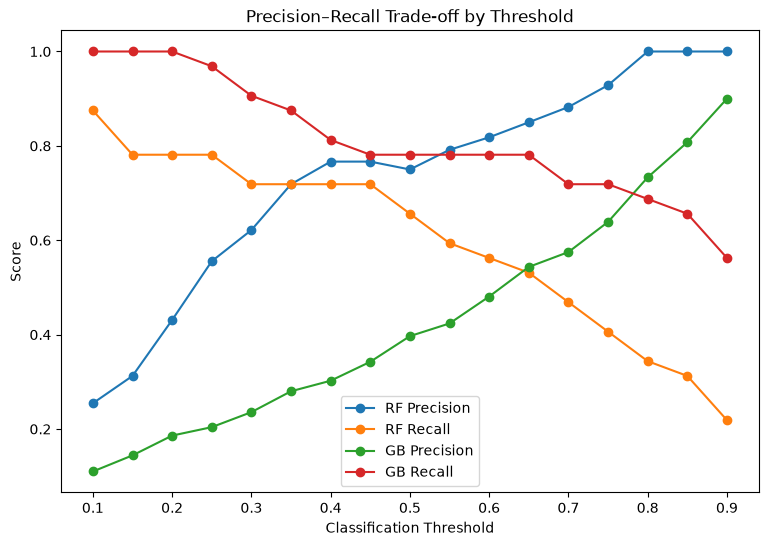

In [52]:
plt.figure(figsize=(9, 6))

plt.plot(
    rf_threshold_results["Threshold"],
    rf_threshold_results["Precision"],
    marker="o",
    label="RF Precision"
)

plt.plot(
    rf_threshold_results["Threshold"],
    rf_threshold_results["Recall"],
    marker="o",
    label="RF Recall"
)

plt.plot(
    gb_threshold_results["Threshold"],
    gb_threshold_results["Precision"],
    marker="o",
    label="GB Precision"
)

plt.plot(
    gb_threshold_results["Threshold"],
    gb_threshold_results["Recall"],
    marker="o",
    label="GB Recall"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall Trade-off by Threshold")
plt.legend()

save_ml_fig(
    "rf_gb_threshold_precision_recall.png"
)

plt.show()

## Classification Threshold Analysis

The default classification threshold of 0.5 is not necessarily optimal for predictive-maintenance applications.

A lower threshold generally increases failure recall by classifying more observations as potential failures, but this also tends to increase false-positive maintenance alarms. Conversely, a higher threshold reduces unnecessary alarms but increases the risk of missing true failures.

Therefore, threshold selection was performed using only the validation set.

Random Forest and Gradient Boosting were evaluated across a range of probability thresholds. Two decision criteria were considered:

- maximizing F1-score as a balanced measure of precision and recall;
- identifying thresholds that maintain high failure recall while minimizing unnecessary false-positive alarms.

The test set remains untouched during this process. The final model and threshold will be fixed using validation results before independent test evaluation.

### Final Model and Threshold Selection

Threshold analysis revealed two distinct operating strategies.

Random Forest achieved the strongest overall F1-score at a threshold of 0.45. At this threshold, the model detected 23 of 32 failures while generating only 7 false-positive alarms, resulting in a precision of approximately 76.7%, recall of 71.9%, and F1-score of 74.2%.

Gradient Boosting provided a more failure-sensitive operating point. At a threshold of 0.65, it detected 25 of 32 failures, corresponding to a recall of approximately 78.1%, while maintaining a precision of approximately 54.3%.

Because the primary objective of predictive maintenance is to reduce missed failures, the Gradient Boosting model with a classification threshold of 0.65 was selected as the primary final model.

The Random Forest model at a threshold of 0.45 is retained as a conservative alternative when unnecessary maintenance alarms carry a relatively high operational cost.

This model and threshold selection was performed exclusively using the validation set. No test-set performance was used in the selection process.

In [53]:
X_test_C = test_df[spc_feature_set]

print("Test shape:", X_test_C.shape)
print("Test failures:", y_test.sum())

Test shape: (1500, 11)
Test failures: 29


In [54]:
# Final test probability prediction

test_prob_final = gb_model_C.predict_proba(
    X_test_C
)[:, 1]

final_threshold = 0.65

test_pred_final = (
    test_prob_final >= final_threshold
).astype(int)

print("Final test prediction completed.")

Final test prediction completed.


In [55]:
final_test_results = evaluate_model(
    y_test,
    test_pred_final,
    test_prob_final,
    "Gradient Boosting - Final Test"
)

pd.DataFrame(
    [final_test_results]
).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Gradient Boosting - Final Test,0.9833,0.5526,0.7241,0.6269,0.9615,0.7463,1454,17,8,21


In [56]:
final_test_cm = confusion_matrix(
    y_test,
    test_pred_final
)

final_test_cm

array([[1454,   17],
       [   8,   21]])

In [57]:
print(
    classification_report(
        y_test,
        test_pred_final,
        target_names=["Normal", "Failure"]
    )
)

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1471
     Failure       0.55      0.72      0.63        29

    accuracy                           0.98      1500
   macro avg       0.77      0.86      0.81      1500
weighted avg       0.99      0.98      0.98      1500



In [58]:
final_validation_results = evaluate_model(
    y_val,
    (gb_val_prob >= 0.65).astype(int),
    gb_val_prob,
    "Validation - GB Threshold 0.65"
)

validation_test_comparison = pd.DataFrame([
    final_validation_results,
    final_test_results
])

validation_test_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Validation - GB Threshold 0.65,0.9813,0.5435,0.7812,0.6410,0.9857,0.7718,1447,21,7,25
1,Gradient Boosting - Final Test,0.9833,0.5526,0.7241,0.6269,0.9615,0.7463,1454,17,8,21


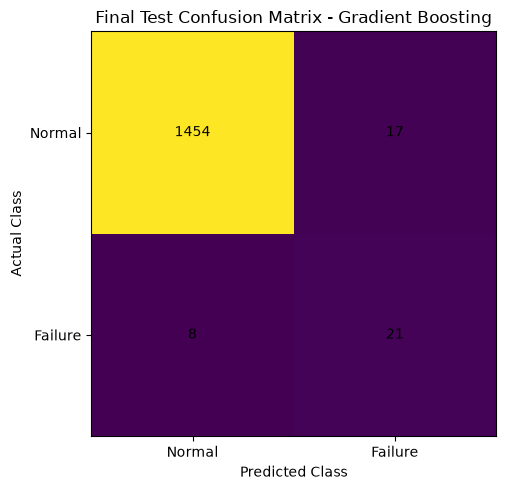

In [59]:
plt.figure(figsize=(6, 5))

plt.imshow(
    final_test_cm,
    interpolation="nearest"
)

plt.title(
    "Final Test Confusion Matrix - Gradient Boosting"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0, 1],
    ["Normal", "Failure"]
)

plt.yticks(
    [0, 1],
    ["Normal", "Failure"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            final_test_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

save_ml_fig(
    "final_gradient_boosting_test_confusion_matrix.png"
)

plt.show()

In [60]:
validation_test_comparison.to_csv(
    "../data/processed/final_model_performance.csv",
    index=False
)

print("Final model performance saved.")

Final model performance saved.


In [61]:
# Extract feature importance from the final Gradient Boosting model

gb_preprocessor = gb_model_C.named_steps["preprocessor"]
gb_classifier = gb_model_C.named_steps["model"]

gb_feature_names = gb_preprocessor.get_feature_names_out()
gb_importances = gb_classifier.feature_importances_

gb_importance_df = pd.DataFrame({
    "Feature": gb_feature_names,
    "Importance": gb_importances
})

gb_importance_df["Feature"] = (
    gb_importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

gb_importance_df = gb_importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

gb_importance_df.round(4)

,Feature,Importance
0,Rotational speed [rpm],0.3467
1,Mechanical power [kW],0.2697
2,Tool wear [min],0.2046
3,Temperature difference [K],0.0905
4,Torque [Nm],0.0758
5,Process temperature [K],0.0058
6,Air temperature [K],0.0050
7,Type_M,0.0010
8,Type_L,0.0006
9,RPM_SPC_Alarm,0.0002


In [62]:
top_gb_features = gb_importance_df.head(12)

top_gb_features.round(4)

,Feature,Importance
0,Rotational speed [rpm],0.3467
1,Mechanical power [kW],0.2697
2,Tool wear [min],0.2046
3,Temperature difference [K],0.0905
4,Torque [Nm],0.0758
5,Process temperature [K],0.0058
6,Air temperature [K],0.0050
7,Type_M,0.0010
8,Type_L,0.0006
9,RPM_SPC_Alarm,0.0002


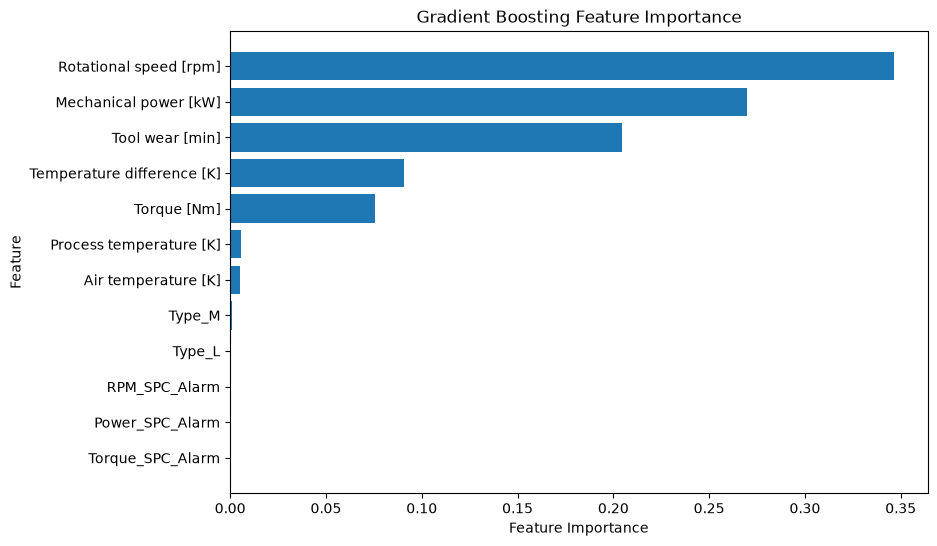

In [63]:
plot_gb_importance = (
    gb_importance_df
    .head(12)
    .sort_values("Importance")
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_gb_importance["Feature"],
    plot_gb_importance["Importance"]
)

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

save_ml_fig(
    "gradient_boosting_feature_importance.png"
)

plt.show()

In [64]:
from sklearn.inspection import permutation_importance

In [65]:
perm_result = permutation_importance(
    gb_model_C,
    X_val_C,
    y_val,
    scoring="average_precision",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "Feature": X_val_C.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_STD": perm_result.importances_std
})

permutation_df = permutation_df.sort_values(
    "Importance_Mean",
    ascending=False
).reset_index(drop=True)

permutation_df.round(4)

,Feature,Importance_Mean,Importance_STD
0,Mechanical power [kW],0.5909,0.0180
1,Tool wear [min],0.3325,0.0235
2,Rotational speed [rpm],0.1001,0.0346
3,Torque [Nm],0.0859,0.0346
4,Type,0.0078,0.0053
5,Process temperature [K],0.0076,0.0037
6,Power_SPC_Alarm,0.0000,0.0000
7,Torque_SPC_Alarm,0.0000,0.0000
8,Air temperature [K],-0.0024,0.0012
9,RPM_SPC_Alarm,-0.0073,0.0024


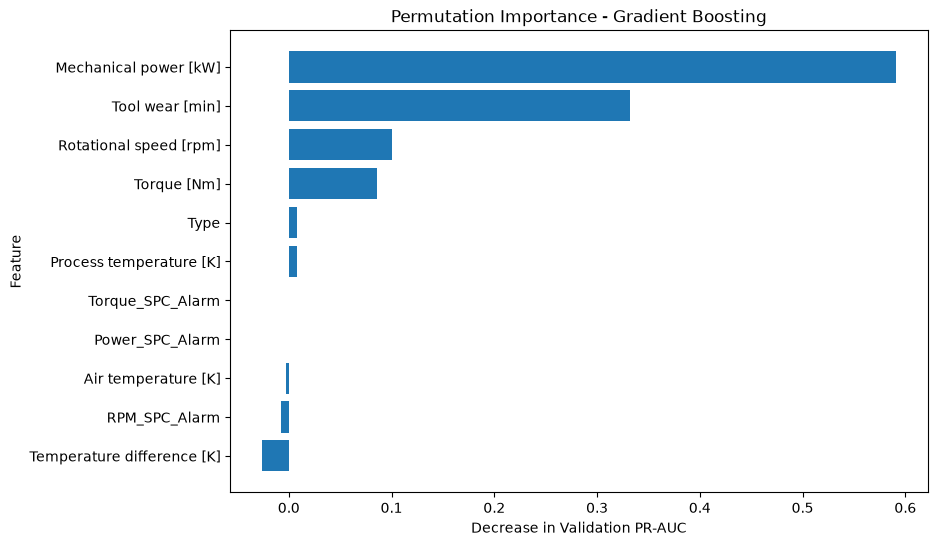

In [66]:
plot_perm = (
    permutation_df
    .head(12)
    .sort_values("Importance_Mean")
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_perm["Feature"],
    plot_perm["Importance_Mean"]
)

plt.title("Permutation Importance - Gradient Boosting")
plt.xlabel("Decrease in Validation PR-AUC")
plt.ylabel("Feature")

save_ml_fig(
    "gradient_boosting_permutation_importance.png"
)

plt.show()

## Gradient Boosting Feature Importance

Feature importance analysis was performed on the final Gradient Boosting model to investigate which process variables contributed most strongly to failure prediction.

Tree-based feature importance measures how frequently and effectively each variable is used to reduce prediction error across the ensemble.

However, feature importance does not indicate the direction of an effect and should not be interpreted as evidence of causality. A highly important variable may represent high-risk values, low-risk values, threshold effects, or interactions with other variables.

Because several mechanical variables are strongly related, particularly torque, rotational speed, and engineered mechanical power, built-in tree importance may distribute predictive contribution across correlated features.

Permutation importance was therefore additionally evaluated using validation PR-AUC. Each feature was randomly permuted while all other variables were left unchanged. A large reduction in PR-AUC indicates that the model relies strongly on the information contained in that feature.

These analyses identify predictive risk indicators rather than direct causal mechanisms of machine failure.

### Role of SPC Features in Failure Prediction

Feature-importance analysis showed that the SPC alarm variables contributed very little to the final Gradient Boosting model.

Both built-in tree importance and permutation importance indicated that the model relied primarily on continuous mechanical operating variables, particularly mechanical power, tool wear, rotational speed, and torque.

The limited contribution of the SPC alarm variables is reasonable because these indicators are threshold-based transformations of continuous variables that are already available to the machine-learning model.

Furthermore, Gradient Boosting can learn non-linear decision thresholds directly from the failure labels. Therefore, fixed SPC control limits do not necessarily correspond to the operating boundaries that best distinguish machine failures.

This result highlights an important distinction between the two analytical approaches:

- SPC is primarily designed to identify statistically unusual process behavior and support interpretable process monitoring.
- Machine learning is directly optimized to distinguish failure and non-failure observations using multivariate patterns.

Therefore, SPC should be interpreted as a complementary process-monitoring layer rather than the primary failure-prediction mechanism in this study.

Permutation importance identified mechanical power and tool wear as the strongest predictive features, followed by rotational speed and torque. These variables should be interpreted as predictive risk indicators rather than confirmed causal factors.

In [67]:
diagnostic_test = test_df.copy()

diagnostic_test["Predicted_Failure"] = test_pred_final
diagnostic_test["Failure_Probability"] = test_prob_final

diagnostic_test[
    [
        "Machine failure",
        "Predicted_Failure",
        "Failure_Probability"
    ]
].head()

,Machine failure,Predicted_Failure,Failure_Probability
0,0,0,0.007987
1,0,0,0.008181
2,0,0,0.145648
3,0,0,0.013626
4,0,0,0.019559


In [68]:
failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]

mode_results = []

for mode in failure_modes:

    mode_df = diagnostic_test[
        (diagnostic_test["Machine failure"] == 1) &
        (diagnostic_test[mode] == 1)
    ]

    total = len(mode_df)

    detected = mode_df["Predicted_Failure"].sum()

    detection_rate = (
        detected / total * 100
        if total > 0 else np.nan
    )

    avg_probability = (
        mode_df["Failure_Probability"].mean()
        if total > 0 else np.nan
    )

    mode_results.append({
        "Failure Mode": mode,
        "Actual Failures": total,
        "Detected": detected,
        "Missed": total - detected,
        "Detection Rate (%)": detection_rate,
        "Mean Failure Probability": avg_probability
    })

failure_mode_summary = pd.DataFrame(mode_results)

failure_mode_summary.round(3)

,Failure Mode,Actual Failures,Detected,Missed,Detection Rate (%),Mean Failure Probability
0,TWF,7,1,6,14.286,0.325
1,HDF,0,0,0,NaN,NaN
2,PWF,7,7,0,100.000,0.978
3,OSF,17,16,1,94.118,0.905
4,RNF,0,0,0,NaN,NaN


In [69]:
important_features = [
    "Mechanical power [kW]",
    "Tool wear [min]",
    "Rotational speed [rpm]",
    "Torque [Nm]"
]

mode_feature_profiles = []

for mode in failure_modes:

    mode_df = diagnostic_test[
        (diagnostic_test["Machine failure"] == 1) &
        (diagnostic_test[mode] == 1)
    ]

    if len(mode_df) == 0:
        continue

    row = {
        "Failure Mode": mode,
        "Count": len(mode_df)
    }

    for feature in important_features:
        row[feature] = mode_df[feature].mean()

    mode_feature_profiles.append(row)

mode_feature_profiles = pd.DataFrame(
    mode_feature_profiles
)

mode_feature_profiles.round(3)

,Failure Mode,Count,Mechanical power [kW],Tool wear [min],Rotational speed [rpm],Torque [Nm]
0,TWF,7,5.801,210.429,1686.000,35.400
1,PWF,7,9.548,115.143,1364.857,66.943
2,OSF,17,8.236,207.588,1362.118,57.818


In [70]:
diagnostic_test["Failure_Mode_Count"] = (
    diagnostic_test[failure_modes]
    .sum(axis=1)
)

unexplained_failures = diagnostic_test[
    (diagnostic_test["Machine failure"] == 1) &
    (diagnostic_test["Failure_Mode_Count"] == 0)
]

print(
    "Failures with no recorded failure mode:",
    len(unexplained_failures)
)

print(
    "Detected by final model:",
    unexplained_failures[
        "Predicted_Failure"
    ].sum()
)

Failures with no recorded failure mode: 2
Detected by final model: 1


## Post-hoc Failure Mode Diagnosis

Failure-mode variables (TWF, HDF, PWF, OSF, and RNF) were not used as predictive inputs because they directly describe failure outcomes and would introduce target leakage.

Instead, they were used after final model evaluation to investigate which failure mechanisms were successfully detected by the Gradient Boosting model.

Failure-mode-specific detection rates and operating profiles were compared using mechanical power, tool wear, rotational speed, and torque, which had previously emerged as the strongest predictive variables.

Because inconsistencies between the `Machine failure` target and individual failure-mode indicators were identified during EDA, failure-mode diagnosis was restricted to observations where `Machine failure = 1`.

This analysis is intended as post-hoc diagnostic interpretation rather than causal identification.

### Failure-Mode-Specific Diagnostic Performance

Post-hoc analysis revealed substantial differences in predictive performance across recorded failure modes.

The final Gradient Boosting model detected all observed PWF cases and approximately 94% of OSF cases in the test set. In contrast, only approximately 14% of TWF cases were detected.

The operating profiles provide a possible predictive explanation for this difference. PWF observations exhibited particularly high mechanical power and torque, while OSF observations combined relatively high mechanical power, torque, and tool wear. These variables were also identified as the strongest predictors in the Gradient Boosting feature-importance analyses.

TWF observations showed high tool wear but substantially lower torque and mechanical power. This suggests that high tool wear alone was insufficient for the final multivariate model to classify many TWF observations as failures.

Therefore, the final model appears particularly effective at identifying power- and load-related failure patterns, while remaining less sensitive to some tool-wear-dominant failures.

These results represent predictive associations rather than causal mechanisms. HDF and RNF could not be evaluated in the test subset because no corresponding Machine-failure-positive cases were observed.

In [71]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    gb_model_C,
    "../models/final_gradient_boosting_model.pkl"
)

joblib.dump(
    spc_feature_set,
    "../models/final_feature_set.pkl"
)

print("Final model and feature set saved.")

Final model and feature set saved.


In [72]:
joblib.dump(
    0.65,
    "../models/final_threshold.pkl"
)

['../models/final_threshold.pkl']